# ATL Spoke ridership

**Atlanta Beltline autonomous shuttle pilot, operated by Beep.**
What happened in June and July 2026, and what it cost.

> **Version 2.** The first version of this report costed the pilot against the \$1.75 million
> state grant alone. Reporting from the [AJC](https://www.ajc.com/news/2026/06/atlanta-beltline-study-biased-toward-autonomous-shuttles-complaint-alleges/) and others puts the project's total cost at
> \$3 million, the balance being roughly \$1.25 million from the Atlanta Beltline that may be
> partly in-kind rather than cash. This version shows both figures side by side throughout.

- **July cost \$191 per rider against the pilot's full \$3 million budget, or \$112 against the
  \$1.75 million state grant alone.** Even the lower figure is 7.6 times a MARTA bus ride; the
  higher one is about 13 times. This report shows both throughout.
- **On the full budget, that figure swings from \$144 to \$239 depending on when the money was
  spent.** Neither the timing of spending nor the makeup of the non-grant \$1.25 million has been
  published.
- **Ridership fell 12.8 percent in July, but it tracks the World Cup ending, not a cut in
  service.** Demand away from the tournament grew 59 percent over the same two months.

In [1]:
import sys, warnings
from pathlib import Path
from datetime import date

import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd() / "src"))
import service_parameters as sp

BLUE, ORANGE, AQUA, RED, YELLOW = "#2a78d6", "#eb6834", "#1baf7a", "#e34948", "#eda100"
INK, INK2, INK3 = "#0d1013", "#4c565e", "#78838b"
RULE, SURFACE = "#dce1e4", "#ffffff"

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 120, "font.size": 9.5, "text.color": INK,
    "axes.labelcolor": INK2, "axes.edgecolor": RULE, "axes.linewidth": 0.8,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": RULE, "grid.linewidth": 0.7,
    "xtick.color": INK2, "ytick.color": INK2, "xtick.labelsize": 8.5, "ytick.labelsize": 8.5,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
    "legend.fontsize": 8.5,
})

daily = pd.read_csv("data/daily_ridership.csv", parse_dates=["date"]).sort_values("date")
# Nullable integer, so 2026-07-26 stays missing rather than becoming a zero.
daily["boardings"] = daily.boardings.astype("Int64")
daily["match_day"] = daily.date.isin(pd.to_datetime(sp.ATLANTA_MATCH_DAYS))
daily["weekday"] = daily.date.dt.day_name()
daily = daily.reset_index(drop=True)

WCS, WCE = pd.Timestamp(sp.WORLD_CUP_START), pd.Timestamp(sp.WORLD_CUP_END)
pre = daily[daily.date < WCS]
during = daily[(daily.date >= WCS) & (daily.date <= WCE)]
post = daily[daily.date > WCE]
jun = daily[(daily.date >= "2026-06-01") & (daily.date <= "2026-06-30")]
jul = daily[daily.date >= "2026-07-01"]


def frame(ax, title, sub=None, ylab=None):
    ax.set_title(title, loc="left", fontsize=11.5, color=INK, pad=16 if sub else 9)
    if sub:
        ax.text(0, 1.03, sub, transform=ax.transAxes, fontsize=8.5, color=INK3)
    ax.set_ylabel(ylab or "", fontsize=8.5)
    return ax


def table(headers, rows, align=None, note=None):
    al = align or (["left"] + ["right"] * (len(headers) - 1))
    th = "".join(
        f'<th style="text-align:{a};padding:7px 14px 7px 0;border-bottom:1.5px solid {INK2};'
        f'font-size:11px;letter-spacing:.06em;text-transform:uppercase;color:{INK2};'
        f'font-weight:600">{h}</th>' for h, a in zip(headers, al))
    body = ""
    for r in rows:
        tds = "".join(
            f'<td style="text-align:{a};padding:7px 14px 7px 0;'
            f'border-bottom:1px solid {RULE};font-variant-numeric:tabular-nums">{v}</td>'
            for v, a in zip(r, al))
        body += f"<tr>{tds}</tr>"
    cap = (f'<div style="font-size:12.5px;color:{INK3};margin-top:9px">{note}</div>'
           if note else "")
    display(HTML(
        f'<div class="mathjax_ignore tex2jax_ignore" '
        f'style="font-family:-apple-system,Segoe UI,sans-serif;max-width:760px">'
        f'<table style="border-collapse:collapse;width:100%;font-size:13.5px;color:{INK}">'
        f"<thead><tr>{th}</tr></thead><tbody>{body}</tbody></table>{cap}</div>"))

In [2]:
cards = [("Riders in June", "1,497", "30 days of service", INK),
         ("Riders in July", "1,306", "Down 12.8 percent", ORANGE),
         ("Change", "-191", "riders", ORANGE),
         ("Cost per rider, July", "$191", "$3M total &middot; $112 on grant alone", INK)]
cells = "".join(
    f'<div style="flex:1;min-width:150px;border:1px solid {RULE};padding:14px 16px 16px">'
    f'<div style="font-size:10.5px;letter-spacing:.09em;text-transform:uppercase;'
    f'color:{INK3};font-weight:600">{lab}</div>'
    f'<div style="font-size:30px;font-weight:700;color:{c};margin-top:7px;'
    f'font-variant-numeric:tabular-nums">{val}</div>'
    f'<div style="font-size:12px;color:{INK2};margin-top:6px">{note}</div></div>'
    for lab, val, note, c in cards)
display(HTML(f'<div class="mathjax_ignore tex2jax_ignore" '
             f'style="display:flex;gap:10px;flex-wrap:wrap;max-width:820px;'
             f'font-family:-apple-system,Segoe UI,sans-serif">{cells}</div>'))

## Ridership spiked on World Cup Match Days, but declined in July

ATL Spoke carried 1,306 riders in July, down from 1,497 in June. The amount of service on
offer did not shrink. The shuttle ran almost the same number of hours in both months, so this
is not a story about the operator cutting back.

What changed was the World Cup. Atlanta hosted five matches at Mercedes-Benz Stadium in June
and three in July, and ridership followed the tournament closely. Match days averaged 78 riders
against 51 on other tournament days. The two busiest days of the whole record were not match
days at all, but 13 and 14 June, the tournament's opening weekend.

In the eleven recorded days after the tournament ended, ridership settled at about 34 riders a
day. That is higher than the 22 a day recorded before the tournament began. Some of that rise is
ordinary growth in a service that had only just launched, so it should not all be read as an
after-effect of the tournament.

One day, 26 July, has no reading in the source data. It is left out of every average here rather
than counted as a zero.

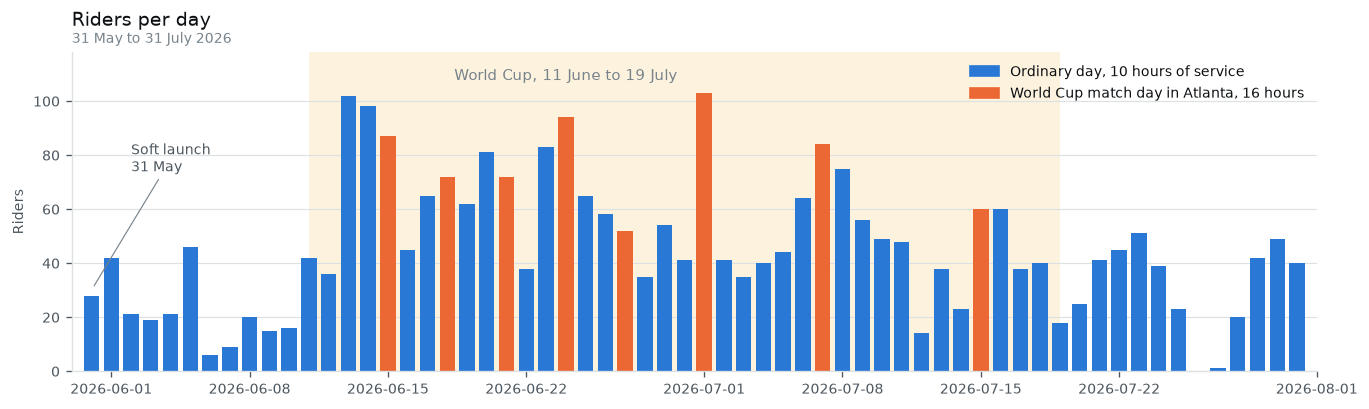

In [3]:
fig, ax = plt.subplots(figsize=(11.5, 3.5))
ax.axvspan(WCS, WCE, color=YELLOW, alpha=0.13, lw=0, zorder=0)
# astype(float) turns pd.NA into NaN, which matplotlib draws as a gap.
ax.bar(daily.date, daily.boardings.astype(float), width=0.78, zorder=2,
       color=[ORANGE if m else BLUE for m in daily.match_day])
ax.set_ylim(0, 118)
ax.set_xlim(daily.date.min() - pd.Timedelta(days=1), daily.date.max() + pd.Timedelta(days=1))
ax.annotate("World Cup, 11 June to 19 July", xy=(pd.Timestamp("2026-06-24"), 112),
            ha="center", va="top", fontsize=9, color=INK3)
ax.annotate("Soft launch\n31 May", xy=(pd.Timestamp("2026-05-31"), 30),
            xytext=(pd.Timestamp("2026-06-02"), 74), ha="left", fontsize=8.5, color=INK2,
            arrowprops=dict(arrowstyle="-", color=INK3, lw=0.7, shrinkA=0, shrinkB=3))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="Ordinary day, 10 hours of service"),
                   Patch(color=ORANGE, label="World Cup match day in Atlanta, 16 hours")],
          loc="upper right")
frame(ax, "Riders per day", "31 May to 31 July 2026", "Riders")
ax.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

## The Beep bus service is extraordinarily expensive compared to other transportation modes

The pilot has a \$3 million total budget. A \$1.75 million grant from the Georgia Transportation
Efficiency Authority covers about 58 percent of it; the Atlanta Beltline covers the rest. We
treat the full \$3 million as running cost, because the vehicles are leased and the only capital
spending disclosed is on signs and similar small items. That works out at \$250,000 a month.

**A caveat on that \$3 million.** The Beltline's roughly \$1.25 million share is never broken down
publicly, and at least one account describes it as partly in-kind rather than cash, meaning staff
time, existing infrastructure or similar contributions rather than a check written. The board
also approved the budget roughly a year before service launched, so some of it may be pre-launch
setup rather than monthly operating cost.

Because that split is unresolved, the tables and charts below carry **both** figures: one against
the full \$3 million, which is the project's understood total in news reporting including the
[AJC](https://www.ajc.com/news/2026/06/atlanta-beltline-study-biased-toward-autonomous-shuttles-complaint-alleges/), which notes the state covered more than half the bill; and one against the \$1.75 million state
grant alone, which is the narrower, more conservative reading. The truth is likely somewhere
between them. Every conclusion in this report holds under either.

Two other things we do not know. First, whether the money is spent evenly across the year. June and
July are months one to three of the pilot, so if spending is front-loaded these months cost
more than average, not less. Second, how many of the four shuttles actually run at once. We
assume three, based on a 34-minute loop and a shuttle every 12 to 15 minutes.

In [4]:
table(["Measure", "June ($3M)", "July ($3M)", "June (grant only)", "July (grant only)"],
      [["Riders", "1,497", "1,306", "1,497", "1,306"],
       ["Hours the service was open", "330", "328", "330", "328"],
       ["Shuttle hours provided (hours times vehicles)", "990", "984", "990", "984"],
       ["Riders per shuttle hour", "1.51", "1.33", "1.51", "1.33"],
       ["Cost per rider", "$167.00", "$191.42", "$97.42", "$111.66"],
       ["Cost per hour the service was open", "$757.58", "$762.20", "$441.92", "$444.61"],
       ["Cost per shuttle hour", "$252.53", "$254.07", "$147.31", "$148.20"],
       ["Cost per passenger mile", "$238.57", "$273.46", "$139.17", "$159.52"]],
      note="Two cost bases. The first pair uses the full $3 million project budget; the second "
           "uses only the $1.75 million state grant, which is 58 percent of it. Ridership "
           "figures are identical in both, since no cost enters them. Both months bought almost "
           "the same service, so July carried fewer riders for the same money.")

Measure,June ($3M),July ($3M),June (grant only),July (grant only)
Riders,"1,497","1,306","1,497","1,306"
Hours the service was open,330,328,330,328
Shuttle hours provided (hours times vehicles),990,984,990,984
Riders per shuttle hour,1.51,1.33,1.51,1.33
Cost per rider,$167.00,$191.42,$97.42,$111.66
Cost per hour the service was open,$757.58,$762.20,$441.92,$444.61
Cost per shuttle hour,$252.53,$254.07,$147.31,$148.20
Cost per passenger mile,$238.57,$273.46,$139.17,$159.52


In [5]:
table(["If the money is spent", "Shuttles", "Cost per rider", "Cost per hour open",
       "Cost per shuttle hour"],
      [["Evenly across the year (base case)", "3", "$191.42", "$762.20", "$254.07"],
       ["Evenly across the year (base case)", "4", "$191.42", "$762.20", "$190.55"],
       ["More heavily early, plus 25 percent", "3", "$239.28", "$952.74", "$317.58"],
       ["More heavily early, plus 25 percent", "4", "$239.28", "$952.74", "$238.19"],
       ["More heavily later, minus 25 percent", "3", "$143.57", "$571.65", "$190.55"],
       ["More heavily later, minus 25 percent", "4", "$143.57", "$571.65", "$142.91"]],
      note="Cost per rider lands between $144 and $239 depending on when the money was spent. "
           "The number of shuttles running only changes the cost per shuttle hour. On the "
           "grant-only basis every figure here is 58 percent of what is shown, so the "
           "equivalent range is $84 to $140.")

If the money is spent,Shuttles,Cost per rider,Cost per hour open,Cost per shuttle hour
Evenly across the year (base case),3,$191.42,$762.20,$254.07
Evenly across the year (base case),4,$191.42,$762.20,$190.55
"More heavily early, plus 25 percent",3,$239.28,$952.74,$317.58
"More heavily early, plus 25 percent",4,$239.28,$952.74,$238.19
"More heavily later, minus 25 percent",3,$143.57,$571.65,$190.55
"More heavily later, minus 25 percent",4,$143.57,$571.65,$142.91


### What changes with the August extension

None of the numbers above cover August. On 19 August 2026, timed to the start of the fall
semester, ATL Spoke added a stop at the Atlanta University Center, serving Clark Atlanta
University, Morehouse College, Morehouse School of Medicine and Spelman College by way of a new
leg north of I-20. The fleet, the noon to 10pm hours and the free fare did not change; Beltline
officials describe it as a route extension, not a new service.

This should push cost per route-mile down almost by arithmetic. Our cost model holds monthly
cost flat regardless of route length, so a longer route divides the same dollar figure across
more miles. Cost per passenger mile should move the same way if the new stops lengthen the
average trip, or if they draw more riders, since both put more passenger-miles under the same
monthly cost. Neither is guaranteed. Ridership could fail to grow, or growth at AUC could be
offset by a drop elsewhere on the route.

No published source gives the added route mileage, so we cannot size either effect yet. We plan
to add August data once ABI publishes it, which will let this section move from expectation to
measurement.

## Cost per ride is highest among selected comparable transportation services and modalities

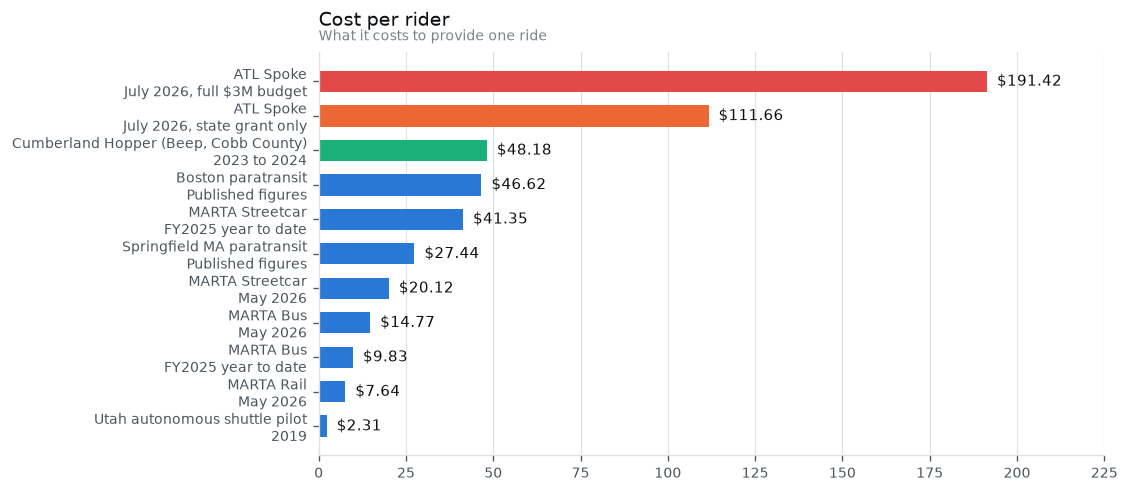

In [6]:
comps = [("ATL Spoke", 191.42, "July 2026, full $3M budget", RED),
         ("ATL Spoke", 111.66, "July 2026, state grant only", ORANGE),
         ("Cumberland Hopper (Beep, Cobb County)", 48.18, "2023 to 2024", AQUA),
         ("Boston paratransit", 46.62, "Published figures", BLUE),
         ("MARTA Streetcar", 41.35, "FY2025 year to date", BLUE),
         ("Springfield MA paratransit", 27.44, "Published figures", BLUE),
         ("MARTA Streetcar", 20.12, "May 2026", BLUE),
         ("MARTA Bus", 14.77, "May 2026", BLUE),
         ("MARTA Bus", 9.83, "FY2025 year to date", BLUE),
         ("MARTA Rail", 7.64, "May 2026", BLUE),
         ("Utah autonomous shuttle pilot", 2.31, "2019", BLUE)]
comps = sorted(comps, key=lambda r: r[1])

fig, ax = plt.subplots(figsize=(9.5, 4.2))
ax.barh(range(len(comps)), [c[1] for c in comps], color=[c[3] for c in comps], height=0.62)
for i, c in enumerate(comps):
    ax.annotate(f"${c[1]:,.2f}", (c[1], i), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK)
ax.set_yticks(range(len(comps)))
ax.set_yticklabels([f"{c[0]}\n{c[2]}" for c in comps], fontsize=8.5)
ax.set_xlim(0, 225)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
frame(ax, "Cost per rider", "What it costs to provide one ride")
plt.tight_layout(); plt.show()

### Beep's earlier Cobb County shuttle

Beep ran the Cumberland Hopper for the Cumberland CID in Cobb County between July 2023 and
December 2024. Two routes linked Cobb Galleria to The Battery. Free to ride, with an attendant
on board, carrying eight passengers at 10 to 15 mph. Like ATL Spoke it was built around events,
in its case Atlanta Braves game nights rather than World Cup matches.

It carried more than 11,000 riders for about \$530,000, which is roughly \$48 a ride. ATL Spoke
costs about 4.0 times that against its full \$3 million budget, or about 2.3 times against the
state grant alone.

The Hopper ran less service, mostly on event evenings, while ATL Spoke runs seven days a week
for 10 to 16 hours. Per ride the Hopper is cheaper. Per hour of service available it may not
be. Its service hours were never published.

### Would it be cheaper to pay people to transport themselves instead of via the Beep bus? Most likely, yes.

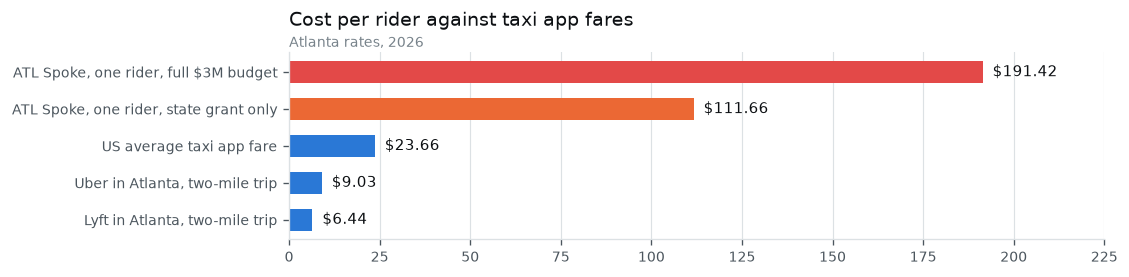

In [7]:
rs = [("ATL Spoke, one rider, full $3M budget", 191.42, RED),
      ("ATL Spoke, one rider, state grant only", 111.66, ORANGE),
      ("US average taxi app fare", 23.66, BLUE),
      ("Uber in Atlanta, two-mile trip", 9.03, BLUE),
      ("Lyft in Atlanta, two-mile trip", 6.44, BLUE)][::-1]
fig, ax = plt.subplots(figsize=(9.5, 2.4))
ax.barh(range(len(rs)), [r[1] for r in rs], color=[r[2] for r in rs], height=0.6)
for i, r in enumerate(rs):
    ax.annotate(f"${r[1]:,.2f}", (r[1], i), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, color=INK)
ax.set_yticks(range(len(rs))); ax.set_yticklabels([r[0] for r in rs], fontsize=8.5)
ax.set_xlim(0, 225)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
frame(ax, "Cost per rider against taxi app fares", "Atlanta rates, 2026")
plt.tight_layout(); plt.show()

The ATL Spoke figure is what the public pays to run the service. A taxi app fare is what the
passenger pays, and excludes the driver's own costs. It also excludes guaranteed wheelchair
access, free travel, and a fixed route. The two are not like-for-like prices.

## July Ridership

June had 20 days inside the World Cup window and 10 outside it. July had 19 inside and 12
outside. So part of the change is that July had a different mix of days, and part is that the
days themselves were quieter. Splitting those two apart gives the whole drop.

In [8]:
jun = daily[(daily.date >= "2026-06-01") & (daily.date <= "2026-06-30")]
jul = daily[daily.date >= "2026-07-01"]

def parts(x):
    w = x[(x.date >= WCS) & (x.date <= WCE)]
    o = x[~x.index.isin(w.index)]
    return (w.boardings.count(), w.boardings.mean(),
            o.boardings.count(), o.boardings.mean())

n_jw, r_jw, n_jn, r_jn = parts(jun)
n_lw, r_lw, n_ln, r_ln = parts(jul)
mix = (n_lw - n_jw) * r_jw + (n_ln - n_jn) * r_jn
rate_wc = n_lw * (r_lw - r_jw)
rate_non = n_ln * (r_ln - r_jn)

table(["Cause", "Riders", "What it means"],
      [["July had fewer tournament days and more ordinary ones", f"{mix:+,.0f}",
        "An effect from the calendar alone"],
       ["Tournament days themselves were quieter", f"{rate_wc:+,.0f}",
        "Atlanta hosted three matches in July, not five"],
       ["Ordinary days were busier than in June", f"{rate_non:+,.0f}",
        "This pushed the other way and cancelled out part of the fall"],
       ["<b>Total change</b>", f"<b>{mix + rate_wc + rate_non:+,.0f}</b>",
        "<b>The three causes add up to the full drop</b>"]],
      align=["left", "right", "left"],
      note="The fall on tournament days is larger than the headline drop. Ordinary days growing "
           "busier offset part of it.")

Cause,Riders,What it means
July had fewer tournament days and more ordinary ones,-43,An effect from the calendar alone
Tournament days themselves were quieter,-288,"Atlanta hosted three matches in July, not five"
Ordinary days were busier than in June,+139,This pushed the other way and cancelled out part of the fall
Total change,-191,The three causes add up to the full drop


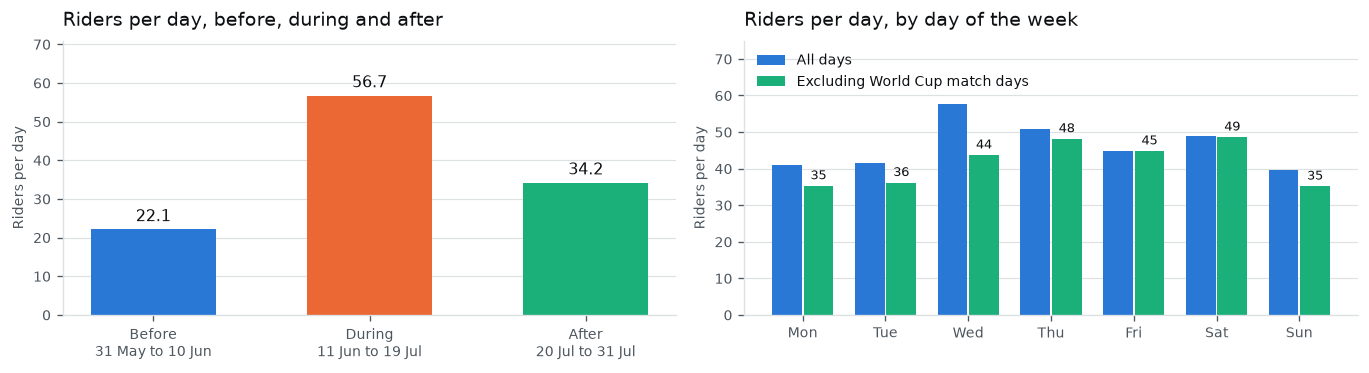

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.2))

vals = [pre.boardings.mean(), during.boardings.mean(), post.boardings.mean()]
labs = ["Before\n31 May to 10 Jun", "During\n11 Jun to 19 Jul", "After\n20 Jul to 31 Jul"]
axes[0].bar(range(3), vals, color=[BLUE, ORANGE, AQUA], width=0.58)
for i, v in enumerate(vals):
    axes[0].annotate(f"{v:.1f}", (i, v), xytext=(0, 5), textcoords="offset points",
                     ha="center", fontsize=9.5, color=INK)
axes[0].set_xticks(range(3)); axes[0].set_xticklabels(labs, fontsize=8.5)
axes[0].set_ylim(0, max(vals) * 1.25)
frame(axes[0], "Riders per day, before, during and after", ylab="Riders per day")

# Three of the eight match days fell on a Wednesday, so the raw weekday average
# is inflated. Both series are shown so that shows up rather than hiding.
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_all = daily.groupby("weekday").boardings.mean().reindex(order)
dow_reg = daily[~daily.match_day].groupby("weekday").boardings.mean().reindex(order)
x = range(7)
axes[1].bar([i - 0.19 for i in x], dow_all, width=0.36, color=BLUE, label="All days")
axes[1].bar([i + 0.19 for i in x], dow_reg, width=0.36, color=AQUA,
            label="Excluding World Cup match days")
for i, v in enumerate(dow_reg):
    axes[1].annotate(f"{v:.0f}", (i + 0.19, v), xytext=(0, 4), textcoords="offset points",
                     ha="center", fontsize=8, color=INK)
axes[1].set_xticks(list(x)); axes[1].set_xticklabels([d[:3] for d in order])
axes[1].set_ylim(0, dow_all.max() * 1.3)
axes[1].legend(loc="upper left")
frame(axes[1], "Riders per day, by day of the week", ylab="Riders per day")
for a in axes:
    a.grid(axis="x", visible=False)
plt.tight_layout(); plt.show()

After the tournament the service settled higher than it started.

There is no reliable weekday or weekend pattern in 62 days. Three of the eight World Cup match
days fell on a Wednesday, which lifts the weekday average. And the one day with no reading,
26 July, is a Sunday. Once both are accounted for, weekends run very slightly above weekdays.

With eight or nine readings per weekday, a single missing day moves the answer. Treat day of
week as unresolved.

## Other Observations

**1. The drop tracks the World Cup ending, not a cut in service.**
Ridership followed the tournament. A low base before it started, a jump from 11 June, then a
fall as it wound down. Atlanta hosted five matches in June but only three in July. This is a
pattern in 62 days of data, not a proven cause. See the limits at the end.

**2. Away from the tournament, ridership grew 59 percent.**
Comparing only the days outside the tournament in each month, daily riders went from 21.5 to
34.2. The monthly total fell while this went up. Some of the rise is ordinary growth in a
service that launched on 5 June, six days before the tournament started.

**3. July carried fewer riders for the same amount of service.**
Longer match-day hours in June balanced out July having an extra day, so both months provided
almost identical service. Riders per hour of shuttle time fell from 1.51 to 1.33.

**4. Match days averaged well above other tournament days, and the gap is not just chance.**
78 riders on an average match day against 51 on other tournament days. A statistical test on
this comparison gives odds of about 1 in 700 that the gap is random, or about 1 in 50 once the
day of the week is accounted for. They were not the busiest days outright, though. 13 June (102
riders) and 14 June (98) were higher than seven of the eight match days, and neither was a match
day. Mercedes-Benz Stadium is not on this route, so match demand likely reaches the shuttle
indirectly, through the rail line and through Lee+White as a destination.

**5. The route was the same in both months, so a route change cannot explain the drop.**
Both months ran the two-mile Phase 1 loop as ABI Short. The extension to the Atlanta University
Center opened in mid-August, after this data ends.

**6. There is no reliable weekday or weekend pattern.**
An earlier version of this report claimed weekdays were busier. That does not hold up. Three of
the eight match days fell on a Wednesday, and the one day with no reading is a Sunday. Correct
for both and weekends run very slightly above weekdays. With 62 days of data this is unresolved.

**7. Each July ride cost \$191 against the full \$3 million budget, or \$112 against the state
grant alone.**
Per rider, that is roughly 13 times a MARTA bus ride on the full budget and 7.6 times on the
grant alone. Per passenger mile, a separate measure, it is 25 times and 14 times what Cobb
County spends on its on-demand service. The gap between the two bases is the Atlanta Beltline's
roughly \$1.25 million share, which has never been broken down publicly.

**8. Beep's earlier Cobb County shuttle cost about \$48 a ride, well below ATL Spoke on either
cost basis.**
The Cumberland Hopper was the same operator running a similar pilot. It ran less service, so
the two are not directly comparable on cost per ride alone.

**9. The main open question is when the pilot's money was actually spent, and what the
non-grant share consists of.**
If more was spent early in the pilot, June and July cost more than the average month, not less.
Monthly spend figures from Beep or ABI would settle it.

## Caveats and considerations

**Correlation is not causality.** Regarding the ridership analysis, we observe patterns between the World Cup tournament and ridership and make assumptions that the World Cup is the prime driver of ridership, however, our analysis does not include rider surveys or other additional data that could provide a stronger causal link.

**Several things were not measured.** Weather, the school calendar, marketing, novelty wearing
off, and other Beltline events are all unrecorded and none can be ruled out.

**One day is missing and another looks like an outage.** 26 July has no reading. 27 July records
a single rider between days of 23 and 20.

**Every cost figure is an estimate built on assumptions**, not on reported cost or hours data.
The \$3 million total pilot budget is corroborated by three sources: the
[AJC](https://www.ajc.com/news/2026/06/atlanta-beltline-study-biased-toward-autonomous-shuttles-complaint-alleges/),
which reports the state covering "more than half the costs" (\$1.75M of \$3M is 58 percent, which
checks out); a [Civic Atlanta piece](https://civicatlanta.org/blog/2026-06-07-complaint-alleges-bias-in-beltline-transit-study)
that states the figure directly; and [BeepThroat](https://www.beepthroat.com/), an open-records
project, which cites a specific Beltline board document approving a \$3 million budget in May
2025. No source we found breaks down what the non-grant ~\$1.25 million actually consists of.

## Data Sources

Ridership comes from two chart-only PDF reports, `ABI Ridership Report June 2026.pdf` and
`ABI Ridership Report July 2026.pdf`. Neither contains a table. We rebuilt every number from the
position of the chart points, then ran sixteen consistency checks. All sixteen pass. They
confirm the totals add up; they do not prove every value sits on the right date. `analysis.ipynb`
has the detail.

Service facts, funding and hours come from
[Atlanta Beltline](https://beltline.org/atl-spoke/) and the
[launch briefing](https://beltline.org/blog/atl-spoke-launches-as-atlanta-s-first-autonomous-public-transit-service/).
The soft launch date comes from
[SaportaReport](https://saportareport.com/atlanta-debuts-its-new-automated-shuttle-atl-spoke-connecting-marta-to-the-beltline/sections/reports/mark-lannaman/).
Match dates come from [WSB-TV](https://www.wsbtv.com/news/local/2026-fifa-world-cup-atlanta-match-schedule-which-countries-will-play-mercedes-benz-stadium/2HYNPLL32FDSZMMSCVCREYPVZU/).

Comparison figures come from [MARTA's scorecard](https://itsmarta.com/kpihome.aspx),
[GovTech](https://www.govtech.com/fs/autonomous-shuttle-set-to-serve-cumberland-ga) and
[Cumberland CID](https://cumberlandcid.org/cumberland-hopper-achieves-10000-riders-as-part-of-av-shuttle-pilot-program/)
for the Hopper,
[the Marietta Daily Journal](https://www.mdjonline.com/news/frontpage/cobbs-on-demand-transit-is-popular-but-expensive-to-operate/article_0c956001-8353-4041-bef6-d5c421145b69.html)
for CobbLinc, and [RideWise](https://getridewise.com/blog/rideshare-pricing-report-2026) for taxi
app fares.

Every assumption behind the cost figures is written down in `src/service_parameters.py`.

## About this analysis

- This work is a side project, not an academic study. Via an Open Records Act request, I requested data from Atlanta Beltline, Inc., on ridership to see if the hype around these buses matched reality. From my review, I don't think it does.
- Methodology and source data is available at https://github.com/mikehikes/beep-analysis
- If you find something that seems off, feel free to email or create an issue in the repository.
- AI (Claude Code) was used to produce these workbooks and code, based on a methodology I provided to Claude. All code, implemented methods, and writing was reviewed and edited by me (human). Sorry, this would have taken too long and I didn't have the time to build this without that assistance!
- As with any analysis work, this work could contain errors and/or could be improved. Any feedback or corrections are appreciated.


-Michael (m@mikeh.dev)

